# 10. Model Family Comparison

This notebook compares multiple model families across multiple feature sets.

Comparison axes:

- Feature sets

  - `base`: existing temporal frequency + gap features
  - `base_plus_pattern`: temporal features + internal draw-pattern history
  - `base_plus_context`: temporal features + calendar/weather context
  - `full_feature_set`: temporal + pattern + context
- Model families
  - heuristic baselines
  - linear model
  - tree-based models
  - classifier chain
  - shallow neural network

The goal is to compare *which combinations remain most stable* under the same time-based holdout and rolling-backtest setup.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)


{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

In [2]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.features import build_model_feature_bundle, describe_feature_sets, load_weather_context
from src.features.temporal_features import time_based_train_test_split
from src.models import build_scaled_mlp_model, build_soft_voting_ensemble_model
from src.models.model_suite import evaluate_number_predictions, evaluate_probability_model, get_probability_matrix, probability_matrix_to_number_lists
from src.models.train_baseline import (
    build_classifier_chain_model,
    build_logistic_regression_model,
)
from src.models.train_random_forest import build_random_forest_model
from src.models.train_xgboost import build_xgboost_model
from src.models.evaluate import compute_calibration_table, compute_precision_at_k_curve, flatten_probability_outputs
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
np.random.seed(42)


## Configuration


In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
BACKTEST_INITIAL_TRAIN_SIZE = 600
BACKTEST_TEST_SIZE = 30
BACKTEST_STEP_SIZE = 30
MAX_BACKTEST_FOLDS = 10
FEATURE_SET_NAMES = [
    "base",
    "base_plus_pattern",
    "base_plus_context",
    "full_feature_set",
]

MODEL_NAMES = [
    "freq_heuristic",
    "gap_heuristic",
    "random_baseline",
    "logistic_regression",
    "random_forest",
    "xgboost",
    "classifier_chain",
    "soft_voting_ensemble",
    "mlp",
]

BACKTEST_MODEL_NAMES = [
    "freq_heuristic",
    "gap_heuristic",
    "random_baseline",
    "logistic_regression",
    "xgboost",
    "classifier_chain",
    "soft_voting_ensemble",
    "mlp",
]


## Load Base Datasets


In [4]:
weather_df = load_weather_context()
feature_bundle = build_model_feature_bundle(window=WINDOW, save_base=False, weather_df=weather_df)
clean_df = feature_bundle.clean_df
y = feature_bundle.y.reset_index(drop=True)
LABEL_COLS = y.columns.tolist()
pattern_df = feature_bundle.pattern.reset_index(drop=True)
context_df = feature_bundle.context.reset_index(drop=True)
feature_sets = feature_bundle.feature_sets

clean_df.shape, weather_df.shape, {k: v.shape for k, v in feature_sets.items()}


((1222, 18),
 (1217, 24),
 {'base': (1202, 90),
  'base_plus_pattern': (1202, 118),
  'base_plus_context': (1202, 121),
  'full_feature_set': (1202, 149)})

## Build Labels


In [5]:
feature_bundle.target_rounds.head()


0    21
1    22
2    23
3    24
4    25
Name: round, dtype: int64

## Build Internal Pattern Features


In [6]:
pattern_df.head()


,sum_main_prev,sum_main_mean_5,sum_main_std_5,sum_main_mean_10,sum_main_std_10,sum_main_mean_20,sum_main_std_20,odd_count_prev,odd_count_mean_5,odd_count_std_5,odd_count_mean_10,odd_count_std_10,odd_count_mean_20,odd_count_std_20,low_count_prev,low_count_mean_5,low_count_std_5,low_count_mean_10,low_count_std_10,low_count_mean_20,low_count_std_20,max_consecutive_run_prev,max_consecutive_run_mean_5,max_consecutive_run_std_5,max_consecutive_run_mean_10,max_consecutive_run_std_10,max_consecutive_run_mean_20,max_consecutive_run_std_20
0,115.0,135.8,38.525316,141.8,32.324054,148.65,30.622102,1.0,2.6,1.341641,3.0,1.247219,3.05,1.190975,4.0,3.0,1.414214,2.7,1.159502,2.45,1.190975,1.0,2.0,0.707107,1.8,0.632456,1.70,0.656947
1,116.0,128.6,38.102493,137.0,32.224904,145.85,30.933332,2.0,2.6,1.341641,2.8,1.229273,2.95,1.190975,4.0,3.4,1.341641,2.9,1.197219,2.60,1.187656,2.0,2.0,0.707107,1.8,0.632456,1.75,0.638666
2,79.0,124.0,43.168275,130.6,36.914917,142.70,34.363536,3.0,2.4,1.140175,2.6,0.966092,2.90,1.165287,5.0,3.6,1.516575,3.1,1.370320,2.70,1.301821,3.0,2.2,0.836660,2.0,0.666667,1.85,0.670820
3,128.0,126.8,42.810046,124.7,31.166399,142.85,34.288674,4.0,2.4,1.140175,2.7,1.059350,2.85,1.089423,4.0,3.6,1.516575,3.4,1.173788,2.70,1.301821,2.0,2.2,0.836660,2.0,0.666667,1.90,0.640723
4,150.0,117.6,25.774018,127.3,32.169862,141.15,32.958147,4.0,2.8,1.303840,2.9,1.100505,2.95,1.099043,2.0,3.8,1.095445,3.3,1.251666,2.75,1.251315,2.0,2.0,0.707107,2.1,0.567646,1.90,0.640723


## Build Calendar and Weather Context Features


In [7]:
context_df.head()


,round,month_sin,month_cos,day_sin,day_cos,year,temp_at_draw,humidity_at_draw,wind_at_draw,pressure_at_draw,precip_at_draw,precip_day_cumulative_at_draw,precip_1h,precip_6h,precip_24h,is_raining,is_snowing,season_spring,season_summer,season_autumn,season_winter,temp_bin_cold,temp_bin_freezing,temp_bin_hot,temp_bin_mild,temp_bin_warm,temp_bin_nan,humidity_bin_dry,humidity_bin_humid,humidity_bin_moderate,humidity_bin_very_humid,humidity_bin_nan
0,21,0.866025,-0.500000,-0.848644,0.528964,2003.0,15.1,65.0,2.7,1005.4,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,22,0.500000,-0.866025,0.571268,0.820763,2003.0,18.7,48.0,0.8,1004.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,23,0.500000,-0.866025,0.897805,-0.440394,2003.0,15.3,46.0,2.8,1007.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,24,0.500000,-0.866025,-0.299363,-0.954139,2003.0,18.0,66.0,1.7,998.6,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,25,0.500000,-0.866025,-0.988468,0.151428,2003.0,17.9,80.0,6.5,1004.0,0.1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Assemble Feature Sets


In [8]:
describe_feature_sets(feature_bundle)


,feature_set,n_features,description
0,base,90,Rolling frequency and gap features only.
1,base_plus_pattern,118,Base features plus draw-level internal pattern...
2,base_plus_context,121,Base features plus calendar and weather context.
3,full_feature_set,149,"Base, internal pattern, and context features c..."


## Model Builders and Evaluation Helpers


In [9]:
def random_predictions(n_rows: int, seed: int):
    rng = np.random.default_rng(seed)
    return [sorted(rng.choice(np.arange(1, 46), size=6, replace=False).tolist()) for _ in range(n_rows)]


def frequency_heuristic_predictions(X_frame: pd.DataFrame):
    freq_cols = [col for col in X_frame.columns if col.startswith("freq_")]
    return probability_matrix_to_number_lists(X_frame[freq_cols].to_numpy())


def gap_heuristic_predictions(X_frame: pd.DataFrame):
    gap_cols = [col for col in X_frame.columns if col.startswith("gap_")]
    return probability_matrix_to_number_lists(X_frame[gap_cols].to_numpy())


def build_mlp_model(random_seed: int):
    return build_scaled_mlp_model(random_seed=random_seed)


def build_model(model_name: str, random_seed: int):
    if model_name == "logistic_regression":
        return build_logistic_regression_model(random_seed=random_seed)
    if model_name == "random_forest":
        return build_random_forest_model(random_seed=random_seed)
    if model_name == "xgboost":
        return build_xgboost_model(random_seed=random_seed)
    if model_name == "classifier_chain":
        return build_classifier_chain_model(random_seed=random_seed)
    if model_name == "soft_voting_ensemble":
        return build_soft_voting_ensemble_model(random_seed=random_seed)
    if model_name == "mlp":
        return build_mlp_model(random_seed=random_seed)
    raise ValueError(model_name)


def evaluate_feature_model_pair(feature_set_name, model_name, X_frame, y_frame, test_ratio=TEST_RATIO, random_seed=RANDOM_SEED):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=test_ratio)
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]

    if model_name == "freq_heuristic":
        result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "gap_heuristic":
        result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "random_baseline":
        result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed), y_test, label_cols=LABEL_COLS)
    else:
        model = build_model(model_name, random_seed=random_seed)
        model.fit(X_train, y_train)
        result = evaluate_probability_model(model_name, model, X_test, y_test)

    return {
        "feature_set": feature_set_name,
        "model": model_name,
        "subset_accuracy": result["subset_accuracy"],
        "number_level_accuracy": result["number_level_accuracy"],
        "avg_hit": result["avg_hit"],
        "hit_std": result["hit_std"],
        "precision_at_6": result["precision_at_6"],
        "recall_at_6": result["recall_at_6"],
        "brier_score": result["brier_score"],
        "n_train_rows": len(X_train),
        "n_test_rows": len(X_test),
    }


def rolling_backtest_feature_model_pair(feature_set_name, model_name, X_frame, y_frame, initial_train_size=BACKTEST_INITIAL_TRAIN_SIZE, test_size=BACKTEST_TEST_SIZE, step_size=BACKTEST_STEP_SIZE, random_seed=RANDOM_SEED, max_folds=MAX_BACKTEST_FOLDS):
    rows = []
    fold_idx = 0
    for train_end in range(initial_train_size, len(X_frame) - test_size + 1, step_size):
        if max_folds is not None and fold_idx >= max_folds:
            break
        test_end = train_end + test_size
        X_train = X_frame.iloc[:train_end].reset_index(drop=True)
        y_train = y_frame.iloc[:train_end].reset_index(drop=True)
        X_test = X_frame.iloc[train_end:test_end].reset_index(drop=True)
        y_test = y_frame.iloc[train_end:test_end].reset_index(drop=True)

        if model_name == "freq_heuristic":
            result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "gap_heuristic":
            result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "random_baseline":
            result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed + fold_idx), y_test, label_cols=LABEL_COLS)
        else:
            model = build_model(model_name, random_seed=random_seed)
            model.fit(X_train, y_train)
            result = evaluate_probability_model(model_name, model, X_test, y_test)

        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "fold": fold_idx,
            "subset_accuracy": result["subset_accuracy"],
            "number_level_accuracy": result["number_level_accuracy"],
            "avg_hit": result["avg_hit"],
            "precision_at_6": result["precision_at_6"],
            "recall_at_6": result["recall_at_6"],
            "brier_score": result["brier_score"],
        })
        fold_idx += 1

    return pd.DataFrame(rows)


def fit_feature_model_for_holdout(feature_set_name, model_name, X_frame, y_frame, test_ratio=TEST_RATIO, random_seed=RANDOM_SEED):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=test_ratio)
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]

    if model_name in {"freq_heuristic", "gap_heuristic", "random_baseline"}:
        return {
            "split": split,
            "probability_matrix": None,
        }

    model = build_model(model_name, random_seed=random_seed)
    model.fit(X_train, y_train)
    probability_matrix = get_probability_matrix(model, X_test)
    return {
        "split": split,
        "probability_matrix": probability_matrix,
    }


## Holdout Comparison


In [10]:
holdout_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for model_name in MODEL_NAMES:
        holdout_rows.append(evaluate_feature_model_pair(feature_set_name, model_name, X_frame, y))
holdout_full_results = pd.DataFrame(holdout_rows)
holdout_summary = holdout_full_results.sort_values(["avg_hit", "number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed holdout comparison in {time.time() - start_time:.1f}s")
holdout_summary.head(12)


Completed holdout comparison in 514.6s


,feature_set,model,subset_accuracy,number_level_accuracy,avg_hit,hit_std,precision_at_6,recall_at_6,brier_score,n_train_rows,n_test_rows
0,base,soft_voting_ensemble,0.0,0.775934,0.958506,0.838852,0.159751,0.159751,0.193813,961,241
1,base,classifier_chain,0.0,0.774643,0.929461,0.804038,0.154910,0.154910,0.199375,961,241
2,base_plus_pattern,random_forest,0.0,0.772614,0.883817,0.870796,0.147303,0.147303,0.135479,961,241
3,base_plus_pattern,xgboost,0.0,0.772614,0.883817,0.856382,0.147303,0.147303,0.168187,961,241
4,base,logistic_regression,0.0,0.772430,0.879668,0.843600,0.146611,0.146611,0.305388,961,241
5,base,xgboost,0.0,0.772245,0.875519,0.879139,0.145920,0.145920,0.175720,961,241
6,base_plus_pattern,logistic_regression,0.0,0.772245,0.875519,0.830601,0.145920,0.145920,0.311706,961,241
7,full_feature_set,classifier_chain,0.0,0.772245,0.875519,0.810372,0.145920,0.145920,0.225681,961,241
8,base_plus_context,soft_voting_ensemble,0.0,0.771692,0.863071,0.768901,0.143845,0.143845,0.195471,961,241
9,full_feature_set,soft_voting_ensemble,0.0,0.771692,0.863071,0.768901,0.143845,0.143845,0.196824,961,241


## Rolling Backtest Comparison


In [11]:
backtest_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for model_name in BACKTEST_MODEL_NAMES:
        backtest_rows.append(rolling_backtest_feature_model_pair(feature_set_name, model_name, X_frame, y))
backtest_full_results = pd.concat(backtest_rows, ignore_index=True)
backtest_summary = backtest_full_results.groupby(["feature_set", "model"], as_index=False).agg(
    folds=("fold", "nunique"),
    mean_subset_accuracy=("subset_accuracy", "mean"),
    mean_number_level_accuracy=("number_level_accuracy", "mean"),
    mean_avg_hit=("avg_hit", "mean"),
    std_avg_hit=("avg_hit", "std"),
).sort_values(["mean_avg_hit", "mean_number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed rolling backtest in {time.time() - start_time:.1f}s")
backtest_summary.head(12)


Completed rolling backtest in 1463.3s


,feature_set,model,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,std_avg_hit
0,base_plus_pattern,xgboost,10,0.0,0.772593,0.883333,0.161207
1,base,random_baseline,10,0.0,0.771407,0.856667,0.145763
2,base_plus_context,random_baseline,10,0.0,0.771407,0.856667,0.145763
3,base_plus_pattern,random_baseline,10,0.0,0.771407,0.856667,0.145763
4,full_feature_set,random_baseline,10,0.0,0.771407,0.856667,0.145763
5,base,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
6,base_plus_context,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
7,base_plus_pattern,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
8,full_feature_set,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
9,full_feature_set,mlp,10,0.0,0.771111,0.850000,0.125953


## Holdout Calibration Diagnostics

This section inspects whether the probability outputs themselves are trustworthy.

We focus on the strongest non-heuristic holdout combinations and examine:

- reliability / calibration curves
- positive vs negative probability distributions
- precision@k ranking behavior


,feature_set,model,avg_hit,precision_at_6,brier_score
0,base,soft_voting_ensemble,0.958506,0.159751,0.193813
1,base,classifier_chain,0.929461,0.154910,0.199375
2,base_plus_pattern,random_forest,0.883817,0.147303,0.135479
3,base_plus_pattern,xgboost,0.883817,0.147303,0.168187


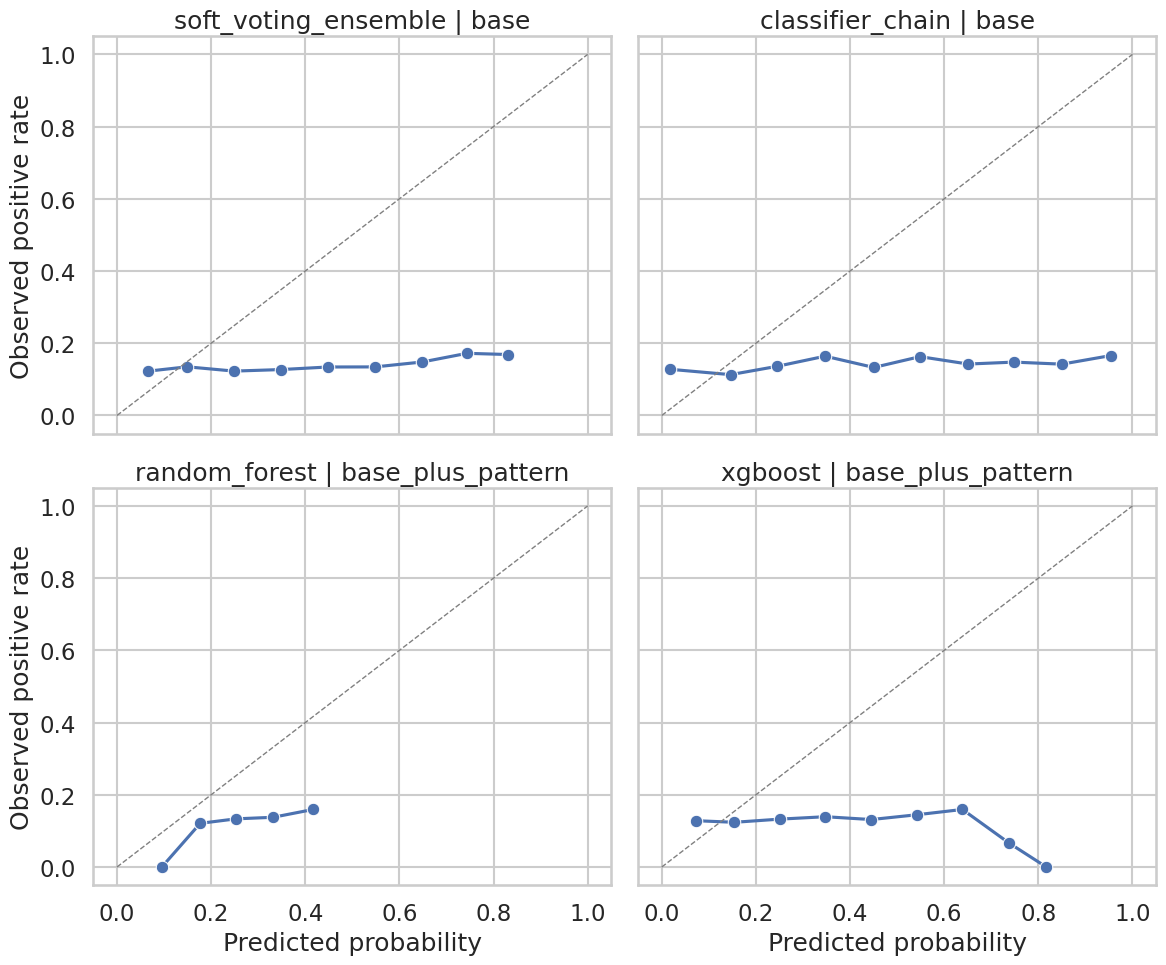

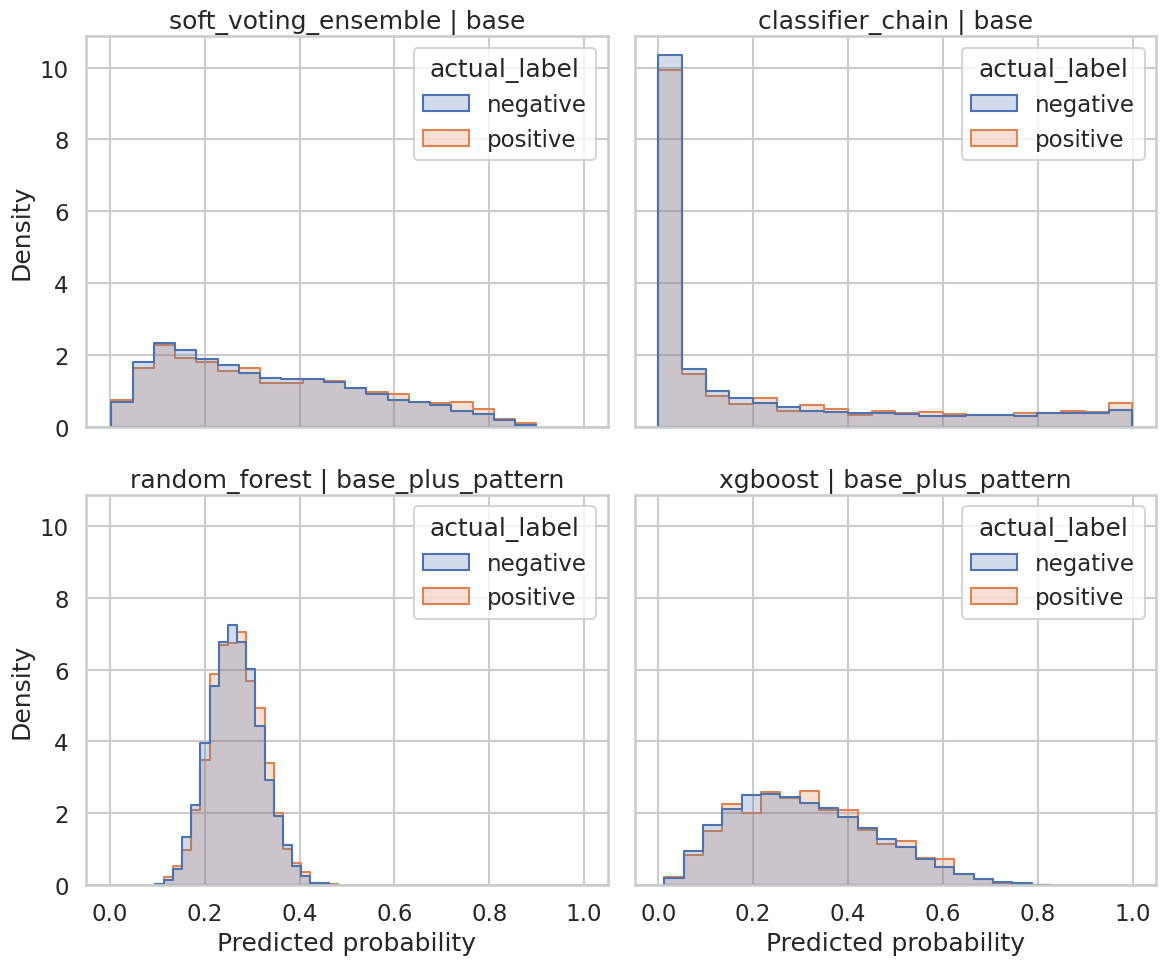

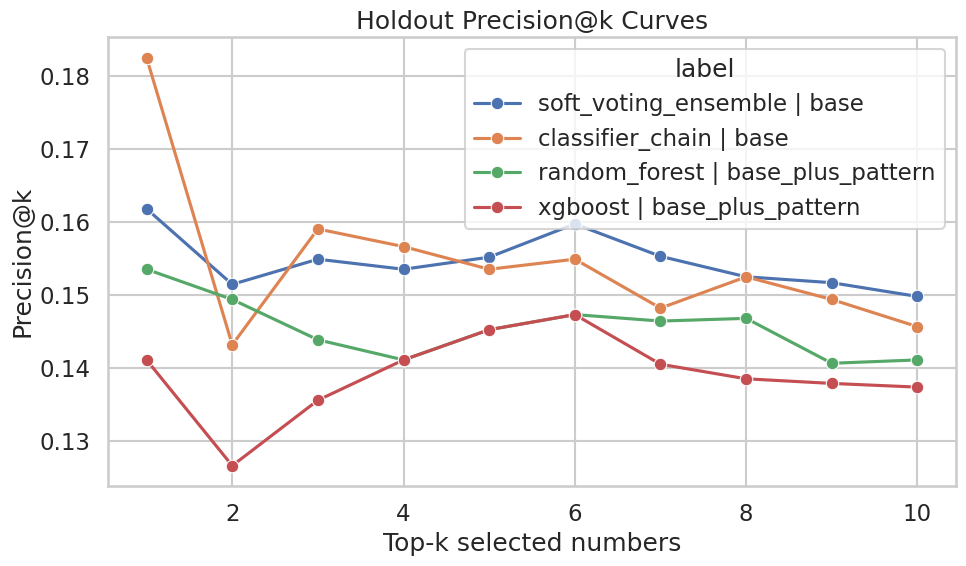

In [12]:
calibration_candidates = holdout_summary.loc[~holdout_summary['model'].isin(['freq_heuristic', 'gap_heuristic', 'random_baseline'])].head(4).copy()
calibration_records = []
calibration_tables = []
precision_k_tables = []
flat_probability_frames = []

for row in calibration_candidates.itertuples():
    feature_set_name = row.feature_set
    model_name = row.model
    fitted = fit_feature_model_for_holdout(feature_set_name=feature_set_name, model_name=model_name, X_frame=feature_sets[feature_set_name], y_frame=y)
    probability_matrix = fitted['probability_matrix']
    split = fitted['split']
    if probability_matrix is None:
        continue

    calibration_table = compute_calibration_table(probability_matrix, split['y_test'], n_bins=10)
    calibration_table['feature_set'] = feature_set_name
    calibration_table['model'] = model_name
    calibration_tables.append(calibration_table)

    precision_table = compute_precision_at_k_curve(probability_matrix, split['y_test'])
    precision_table['feature_set'] = feature_set_name
    precision_table['model'] = model_name
    precision_k_tables.append(precision_table)

    flat_frame = flatten_probability_outputs(probability_matrix, split['y_test'])
    flat_frame['actual_label'] = flat_frame['actual'].map({0: 'negative', 1: 'positive'})
    flat_frame['feature_set'] = feature_set_name
    flat_frame['model'] = model_name
    flat_probability_frames.append(flat_frame)

calibration_full = pd.concat(calibration_tables, ignore_index=True)
precision_k_full = pd.concat(precision_k_tables, ignore_index=True)
flat_probability_full = pd.concat(flat_probability_frames, ignore_index=True)

fig_calibration, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()
for ax, row in zip(axes, calibration_candidates.itertuples()):
    subset = calibration_full[(calibration_full['feature_set'] == row.feature_set) & (calibration_full['model'] == row.model)]
    sns.lineplot(data=subset, x='mean_predicted_probability', y='observed_positive_rate', marker='o', ax=ax)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'{row.model} | {row.feature_set}')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed positive rate')
for ax in axes[len(calibration_candidates):]:
    ax.axis('off')
plt.tight_layout()

fig_probability_density, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()
for ax, row in zip(axes, calibration_candidates.itertuples()):
    subset = flat_probability_full[(flat_probability_full['feature_set'] == row.feature_set) & (flat_probability_full['model'] == row.model)]
    sns.histplot(data=subset, x='predicted_probability', hue='actual_label', bins=20, stat='density', common_norm=False, element='step', ax=ax)
    ax.set_title(f'{row.model} | {row.feature_set}')
    ax.set_xlabel('Predicted probability')
for ax in axes[len(calibration_candidates):]:
    ax.axis('off')
plt.tight_layout()

fig_precision_k, ax = plt.subplots(figsize=(10, 6))
precision_k_full['label'] = precision_k_full['model'] + ' | ' + precision_k_full['feature_set']
sns.lineplot(data=precision_k_full, x='k', y='precision_at_k', hue='label', marker='o', ax=ax)
ax.set_title('Holdout Precision@k Curves')
ax.set_xlabel('Top-k selected numbers')
ax.set_ylabel('Precision@k')
plt.tight_layout()

calibration_summary = calibration_candidates[['feature_set', 'model', 'avg_hit', 'precision_at_6', 'brier_score']].copy()
calibration_summary


## Visual Comparison


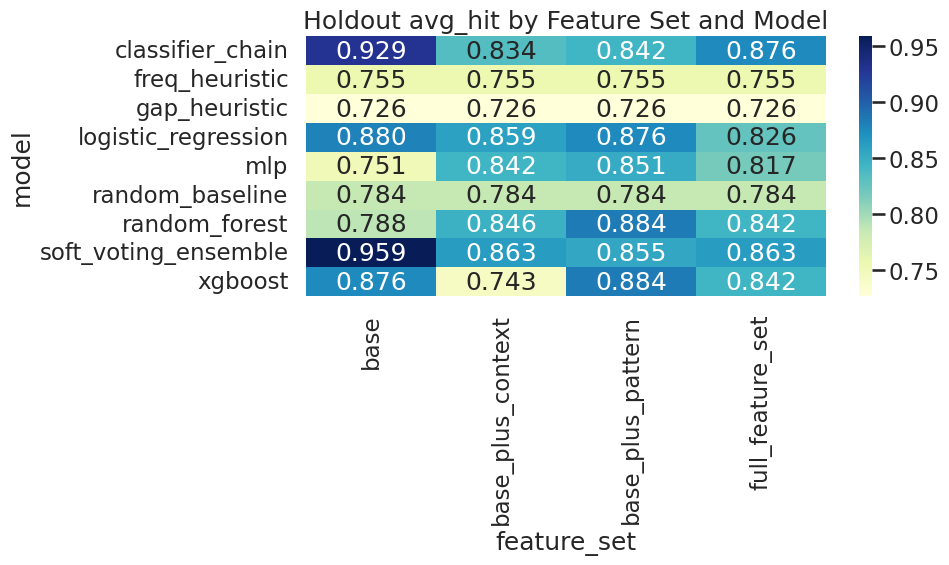

In [13]:
holdout_heatmap = holdout_summary.pivot(index="model", columns="feature_set", values="avg_hit")
fig_holdout_heatmap, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(holdout_heatmap, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Holdout avg_hit by Feature Set and Model")
plt.tight_layout()
plt.show()


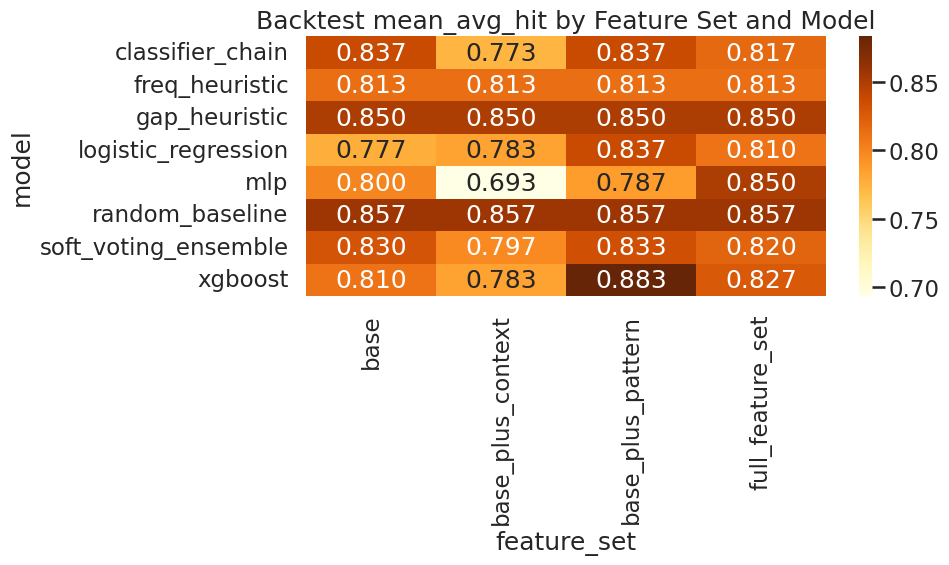

In [14]:
backtest_heatmap = backtest_summary.pivot(index="model", columns="feature_set", values="mean_avg_hit")
fig_backtest_heatmap, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(backtest_heatmap, annot=True, fmt=".3f", cmap="YlOrBr", ax=ax)
ax.set_title("Backtest mean_avg_hit by Feature Set and Model")
plt.tight_layout()
plt.show()


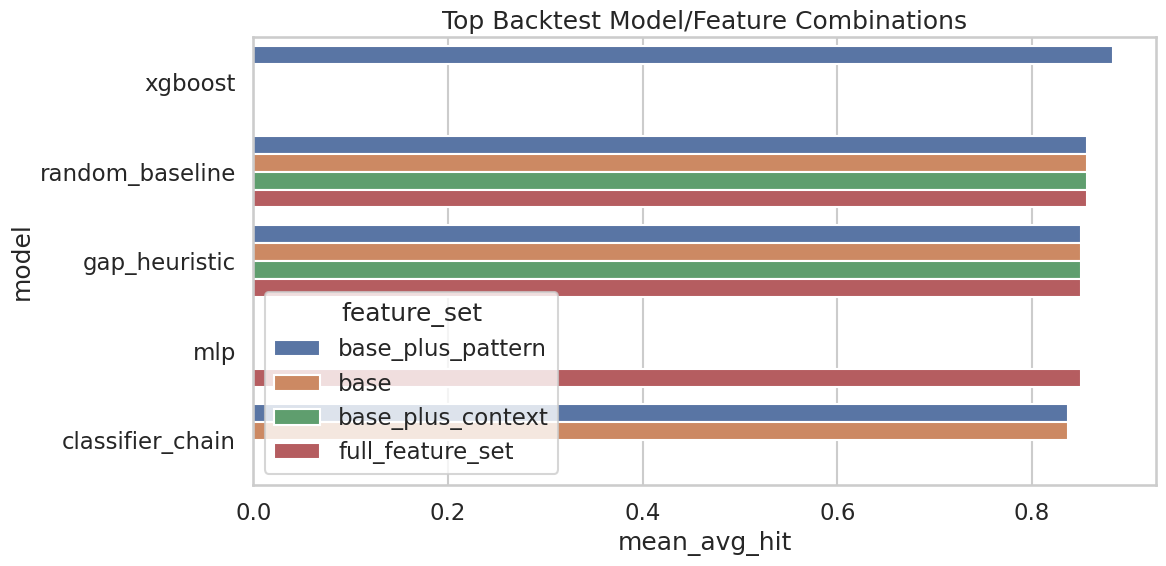

In [15]:
top_backtest = backtest_summary.head(12).copy()
fig_top_compare, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_backtest, x="mean_avg_hit", y="model", hue="feature_set", ax=ax)
ax.set_title("Top Backtest Model/Feature Combinations")
plt.tight_layout()
plt.show()


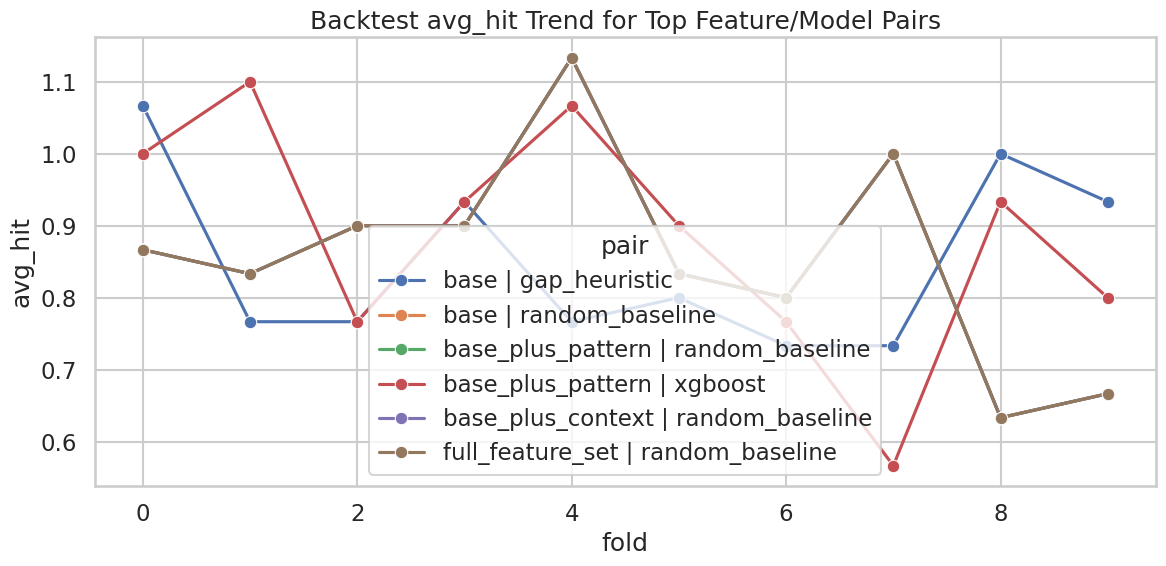

In [16]:
top_pairs = backtest_summary.head(6)[["feature_set", "model"]]
trend_df = backtest_full_results.merge(top_pairs, on=["feature_set", "model"], how="inner")
trend_df["pair"] = trend_df["feature_set"] + " | " + trend_df["model"]
fig_backtest_trend, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=trend_df, x="fold", y="avg_hit", hue="pair", marker="o", ax=ax)
ax.set_title("Backtest avg_hit Trend for Top Feature/Model Pairs")
plt.tight_layout()
plt.show()


## Interpretation Notes


In [17]:
display_cols_holdout = ["feature_set", "model", "avg_hit", "number_level_accuracy"]
display_cols_backtest = ["feature_set", "model", "mean_avg_hit", "mean_number_level_accuracy"]
holdout_summary[display_cols_holdout].head(12), backtest_summary[display_cols_backtest].head(12)


(          feature_set                 model   avg_hit  number_level_accuracy
 0                base  soft_voting_ensemble  0.958506               0.775934
 1                base      classifier_chain  0.929461               0.774643
 2   base_plus_pattern         random_forest  0.883817               0.772614
 3   base_plus_pattern               xgboost  0.883817               0.772614
 4                base   logistic_regression  0.879668               0.772430
 5                base               xgboost  0.875519               0.772245
 6   base_plus_pattern   logistic_regression  0.875519               0.772245
 7    full_feature_set      classifier_chain  0.875519               0.772245
 8   base_plus_context  soft_voting_ensemble  0.863071               0.771692
 9    full_feature_set  soft_voting_ensemble  0.863071               0.771692
 10  base_plus_context   logistic_regression  0.858921               0.771508
 11  base_plus_pattern  soft_voting_ensemble  0.854772          

Use the results conservatively:

- if `base` stays on top, the existing temporal features remain the most stable baseline
- if `base_plus_context` helps only some models, then calendar/weather is a model-dependent auxiliary signal
- if `full_feature_set` helps tree or neural models more than linear models, then feature interactions matter more than raw context alone
- rolling backtest matters more than a single holdout split when making final claims


## Report Export


In [18]:
save_report_figure(fig_holdout_heatmap, "fig_29_model_family_holdout_heatmap.png")
save_report_figure(fig_backtest_heatmap, "fig_30_model_family_backtest_heatmap.png")
save_report_figure(fig_top_compare, "fig_31_model_family_top_comparison.png")
save_report_figure(fig_backtest_trend, "fig_32_model_family_backtest_trend.png")

save_report_table(holdout_summary, "table_23_model_family_holdout_summary.csv")
save_report_table(backtest_summary, "table_24_model_family_backtest_summary.csv")
save_report_table(backtest_full_results, "table_25_model_family_full_results.csv")
print("Saved model family comparison report artifacts.")


save_report_figure(fig_calibration, "fig_33_model_family_calibration_curves.png")
save_report_figure(fig_probability_density, "fig_34_model_family_probability_histograms.png")
save_report_figure(fig_precision_k, "fig_35_model_family_precision_at_k.png")

save_report_table(calibration_summary, "table_26_model_family_calibration_summary.csv")
save_report_table(calibration_full, "table_27_model_family_calibration_bins.csv")
save_report_table(precision_k_full, "table_28_model_family_precision_at_k.csv")


Saved model family comparison report artifacts.


PosixPath('/workspace/reports/tables/table_28_model_family_precision_at_k.csv')